In [3]:
!pip install lime
!pip install tensorflow
!pip install matplotlib

  Using cached typing_extensions-4.5.0-py3-none-any.whl (27 kB)
  Attempting uninstall: typing-extensions
    Found existing installation: typing-extensions 4.12.2
    Uninstalling typing-extensions-4.12.2:
      Successfully uninstalled typing-extensions-4.12.2


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typeguard 4.4.0 requires typing-extensions>=4.10.0, but you have typing-extensions 4.5.0 which is incompatible.
torch 2.4.1 requires typing-extensions>=4.8.0, but you have typing-extensions 4.5.0 which is incompatible.


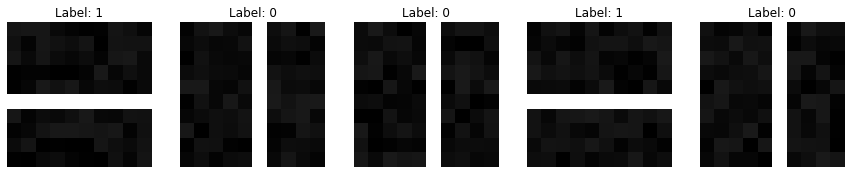

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_images = 100  # Number of images in the dataset
image_size = 10   # Size of each image (10x10)

# Generate synthetic data
data = []
labels = []

for _ in range(num_images):
    # Create a blank image
    image = np.random.rand(image_size, image_size) * 0.1  # Add some random noise
    
    # Randomly decide if the image will have a vertical or horizontal line
    if np.random.rand() > 0.5:
        # Add a vertical line
        image[:, image_size // 2] = 1.0
        label = 0  # Class 0: Vertical line
    else:
        # Add a horizontal line
        image[image_size // 2, :] = 1.0
        label = 1  # Class 1: Horizontal line
    
    data.append(image)
    labels.append(label)

# Convert to NumPy arrays
data = np.array(data)
labels = np.array(labels)

# Reshape data to include channel dimension (required for models)
data = data.reshape(-1, image_size, image_size, 1)

# Normalize data to [0, 1]
data = data.astype('float32')

# Visualize a few examples
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(data[i].squeeze(), cmap='gray')
    ax.set_title(f"Label: {labels[i]}")
    ax.axis('off')
plt.show()

In [13]:
!pip install --upgrade h5py

  Attempting uninstall: h5py
    Found existing installation: h5py 2.10.0
    Uninstalling h5py-2.10.0:
      Successfully uninstalled h5py-2.10.0


  0%|          | 0/500 [00:00<?, ?it/s]

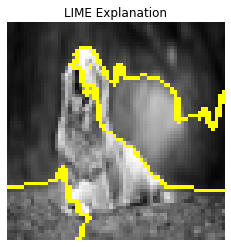

In [33]:
import numpy as np
from PIL import Image
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt

# Load and preprocess the image
image_path = "img01.png"  # Replace with your image path
image = Image.open(image_path).convert('L').resize((64, 64))  # Grayscale, resize to 64x64
image_array = np.array(image).astype('float32') / 255.0  # Normalize to [0, 1]

# Convert grayscale to RGB-like format (3 channels)
image_array = np.stack([image_array] * 3, axis=-1)  # Shape: (64, 64, 3)

# Add batch dimension
image_array = np.expand_dims(image_array, axis=0)  # Shape: (1, 64, 64, 3)

# Define a simple prediction function (replace with your model's predict function)
def predict_fn(images):
    # Example: Random predictions for demonstration
    return np.random.rand(images.shape[0], 2)  # Replace with actual model.predict(images)

# Initialize LIME explainer
explainer = lime_image.LimeImageExplainer()

# Generate explanation
explanation = explainer.explain_instance(
    image_array[0].astype('float64'),  # Ensure float64 for quickshift
    predict_fn,
    top_labels=1,    # Explain the top predicted class
    hide_color=0,    # Mask color
    num_samples=500  # Number of perturbed samples
)

# Visualize the explanation
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.imshow(mark_boundaries(temp.squeeze(), mask))
plt.title("LIME Explanation")
plt.axis('off')
plt.show()

  0%|          | 0/500 [00:00<?, ?it/s]

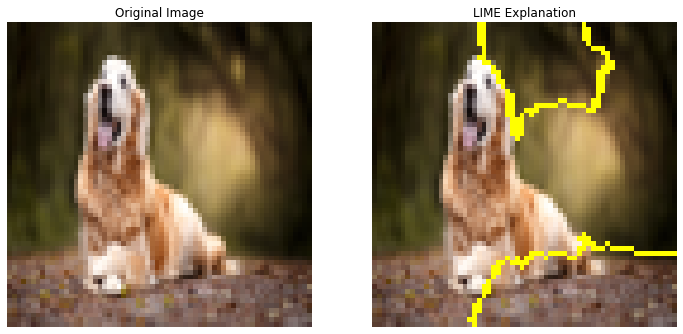

In [40]:
import numpy as np
from PIL import Image
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt

# Load and preprocess the image
image_path = "img01.png"  # Replace with your image path
image = Image.open(image_path).resize((64, 64))  # Resize to 64x64

# Ensure the image is in RGB format (remove alpha channel if present)
if image.mode == 'RGBA':
    image = image.convert('RGB')  # Convert RGBA to RGB by dropping the alpha channel

# Convert the image to a NumPy array and normalize to [0, 1]
image_array = np.array(image).astype('float32') / 255.0

# Add batch dimension
image_array = np.expand_dims(image_array, axis=0)  # Shape: (1, 64, 64, 3)

# Define a simple prediction function (replace with your model's predict function)
def predict_fn(images):
    # Example: Random predictions for demonstration
    return np.random.rand(images.shape[0], 2)  # Replace with actual model.predict(images)

# Initialize LIME explainer
explainer = lime_image.LimeImageExplainer()

# Generate explanation
explanation = explainer.explain_instance(
    image_array[0].astype('float64'),  # Ensure float64 for quickshift
    predict_fn,
    top_labels=1,    # Explain the top predicted class
    hide_color=0,    # Mask color
    num_samples=500  # Number of perturbed samples
)

# Visualize the explanation
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

# Display the original image and the explanation
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Original image
axes[0].imshow(image_array[0])
axes[0].set_title("Original Image")
axes[0].axis('off')

# LIME explanation
axes[1].imshow(mark_boundaries(temp, mask))
axes[1].set_title("LIME Explanation")
axes[1].axis('off')

plt.show()